# Amortized consensus NMF with `CNMFTransformer`

Consensus NMF (cNMF, [Kotliar et al. 2019](https://elifesciences.org/articles/43803)) finds
overlapping gene programs, but choosing the number of programs $k$ requires running hundreds of
independent NMF optimizations at every candidate $k$. `CNMFTransformer` replaces that sweep with a
single **amortized solver**: one lightweight transformer, trained once on a dataset, that factorizes
it for *any* $k$ on demand.

Training samples a random $k$ each step, pushes $R$ independent noise seeds through a slot-attention
stack (with cells as keys/values), decodes each replicate's gene programs $W$, solves the cell
loadings $H$ with a detached FISTA polish, and reduces the $R$ replicates to a differentiable
Sinkhorn consensus. Afterwards a short **measurement phase** sweeps every $k$ under `no_grad` to
produce the stability/error curves.

This notebook uses the Python API (not the Lightning CLI) for two analyses:

1. **Synthetic data with a known $k$** — can the method find it, and how certain can we be?
2. **PBMC3k** — do the recovered programs separate into cell-type markers and pan-cell-type
   programs?

In [1]:
import os

# The FISTA helpers in cellarium.ml.models.nmf are torch.compile-decorated. On CPU the inductor
# compile costs more than it saves at demo scale -- leave compilation ON for real GPU training runs.
os.environ["TORCH_COMPILE_DISABLE"] = "1"

import time

import anndata
import lightning.pytorch as pl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse
import torch
from scipy.optimize import linear_sum_assignment

from cellarium.ml import CellariumAnnDataDataModule, CellariumModule
from cellarium.ml.models import CNMFTransformer
from cellarium.ml.models.cnmf_transformer import (
    export_hot_start,
    plot_k_selection,
    run_measurement_phase,
    plot_density_histograms,
)
from cellarium.ml.models.nmf import kotliar_compute_hvgs
from cellarium.ml.transforms import DivideByScale, Filter, NormalizeTotal
from cellarium.ml.utilities.data import AnnDataField

pl.seed_everything(0)
sc.settings.verbosity = 1

# Explicit CPU: some ops used here have no MPS kernel, and this notebook is sized to run on a laptop.
ACCELERATOR = "cpu"

/Users/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
Seed set to 0


In [2]:
%load_ext autoreload
%autoreload 2

## Helpers

Four small utilities, shared by both analyses. Two of them exist to work around real gotchas, noted
in their docstrings.

In [3]:
def all_transforms(module: CellariumModule) -> list[torch.nn.Module]:
    """Every transform the model was trained behind, in order.

    During `fit` the CPU transforms live in the dataloader's `collate_fn`, but Lightning's
    `teardown` moves them back into the module when `fit` returns. So once `trainer.fit` has
    finished, the datamodule no longer applies them, and anything that pulls batches directly
    (inference, the measurement phase) has to apply them itself.
    """
    return list(module.cpu_transforms) + list(module.transforms)


def transformed_matrix(module, x_ng, var_names_g):
    """Put a whole matrix into the space the model was trained in."""
    batch = {"x_ng": torch.as_tensor(np.asarray(x_ng)), "var_names_g": np.asarray(var_names_g)}
    for transform in all_transforms(module):
        batch |= transform(x_ng=batch["x_ng"], var_names_g=batch["var_names_g"])
    return batch["x_ng"], batch["var_names_g"]


def measurement_batches(datamodule, n_batches, max_epochs=200):
    """Yield up to `n_batches` minibatches from a datamodule's predict dataloader.

    A small in-memory dataset holds only two or three minibatches per epoch, which would leave the
    standard errors on the k-selection curves resting on two or three observations. Re-iterating
    with `set_epoch` reshuffles which cells land together, so each pass gives differently-composed
    batches. For a large out-of-core dataset you would just pass `predict_dataloader()` directly.
    """
    loader = datamodule.predict_dataloader()
    dataset = loader.dataset
    yielded = 0
    for epoch in range(max_epochs):
        if hasattr(dataset, "set_epoch"):
            dataset.set_epoch(epoch)
        for batch in loader:
            yield batch
            yielded += 1
            if yielded >= n_batches:
                return


def match_to_reference(w_inferred_kg, w_reference_kg):
    """Hungarian matching of inferred factors onto reference factors by cosine similarity.

    Returns `order` such that `w_inferred_kg[order][j]` is the inferred factor matched to reference
    factor `j`. The model itself uses Sinkhorn internally because it needs a *differentiable*
    match; for post-hoc evaluation a hard one-to-one assignment is the right tool and leaves no
    ambiguity about ties.
    """
    a = w_inferred_kg / np.linalg.norm(w_inferred_kg, axis=1, keepdims=True).clip(1e-12)
    b = w_reference_kg / np.linalg.norm(w_reference_kg, axis=1, keepdims=True).clip(1e-12)
    rows, cols = linear_sum_assignment(-(a @ b.T))
    order = np.empty(len(cols), dtype=int)
    order[cols] = rows
    return order

### The k-selection figure

`plot_k_selection(model)` is the one-line version. The figure below is a more detailed one, used in
both analyses, with three panels:

1. **Stability** — *within-batch* (initialization variance only, comparable to Kotliar's silhouette)
   and *cross-batch* (which also folds in **sampling** variance). The gap between them says how much
   of the apparent stability is a sampling artifact rather than a property of the data.
2. **Reconstruction error** — on the cells the programs were fit from, and on held-out cells.
3. **Marginal gain per added factor** — the first difference of the held-out error, with propagated
   error bars and a line at zero.

Panel 3 is the one that answers *how certain are we about $k$*. An elbow is a judgement call; the
first difference turns it into a curve you can watch flatten, and the error bars say whether the
remaining gains are distinguishable from noise. All ribbons are $\pm$ 1 standard error across
measurement minibatches.

In [4]:
def plot_selection(model, k_mark=None, title=""):
    """Stability / error / marginal-gain, with standard errors across measurement batches."""
    curves = model.selection_curves()
    k = curves["k"]
    fig, axes = plt.subplots(3, 1, figsize=(7.5, 9), sharex=True)

    for key, label, style, alpha in (
        ("stability", "within-batch (initialization variance)", "-", 1.0),
        ("stability_cross", "cross-batch (+ sampling variance)", "--", 0.65),
    ):
        mean, sem = curves[key], curves[f"{key}_sem"]
        axes[0].plot(k, mean, style, marker="o", ms=3, color="tab:blue", alpha=alpha, label=label)
        axes[0].fill_between(k, mean - sem, mean + sem, color="tab:blue", alpha=0.15)
    axes[0].set_ylabel("stability\n(matched silhouette)")
    axes[0].legend(fontsize=8)

    for key, label, style, alpha in (
        ("error", "same cells", "-", 1.0),
        ("error_cross", "held-out cells", "--", 0.65),
    ):
        mean, sem = curves[key], curves[f"{key}_sem"]
        axes[1].plot(k, mean, style, marker="o", ms=3, color="tab:red", alpha=alpha, label=label)
        axes[1].fill_between(k, mean - sem, mean + sem, color="tab:red", alpha=0.15)
    axes[1].set_ylabel("reconstruction error\n(per-entry MSE)")
    axes[1].legend(fontsize=8)

    gain = -np.diff(curves["error_cross"])
    gain_sem = np.sqrt(curves["error_cross_sem"][1:] ** 2 + curves["error_cross_sem"][:-1] ** 2)
    axes[2].errorbar(k[1:], gain, yerr=gain_sem, fmt="o-", ms=3, capsize=2, color="tab:purple")
    axes[2].axhline(0.0, color="k", lw=0.8, ls=":")
    axes[2].set_ylabel("marginal gain in\nheld-out error")
    axes[2].set_xlabel("number of factors: k")

    for ax in axes:
        ax.grid(alpha=0.25)
        if k_mark is not None:
            ax.axvline(k_mark, color="k", lw=1.0, ls="--", alpha=0.6)
    if title:
        fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def summarize_selection(model):
    """Two quantitative readouts of where k stops buying anything."""
    curves = model.selection_curves()
    k = curves["k"]
    gain = -np.diff(curves["error_cross"])
    gain_sem = np.sqrt(curves["error_cross_sem"][1:] ** 2 + curves["error_cross_sem"][:-1] ** 2)
    significant = gain > gain_sem
    best_stability_k = int(k[np.nanargmax(curves["stability_cross"])])
    last_useful_k = int(k[1:][significant][-1]) if significant.any() else int(k[0])
    print(f"highest cross-batch stability at k = {best_stability_k}")
    print(f"largest k whose marginal gain in held-out error exceeds its own SEM: k = {last_useful_k}")
    return best_stability_k, last_useful_k

---
# 1. Synthetic data with a known number of programs

The generator below builds $X = HW$ with two *kinds* of program, mirroring the biology we care
about:

- **identity programs** — each cell gets exactly one, at high loading, so they appear as discrete
  clusters;
- **activity programs** — graded across every cell type independently of identity, so they appear as
  continuous gradients that no cluster owns.

Each program owns a disjoint block of genes. That makes the rank-$k$ non-negative factorization
essentially unique, so "how many programs are in this data" has an unambiguous answer to check
against.

In [5]:
N_IDENTITY, N_ACTIVITY = 4, 2
K_TRUE = N_IDENTITY + N_ACTIVITY
FACTOR_LABELS = [f"identity {i}" for i in range(N_IDENTITY)] + [f"activity {i}" for i in range(N_ACTIVITY)]


def make_synthetic(n_cells=12_000, n_genes=200, noise=0.05, seed=0):
    """Ground-truth NMF data. Returns (x_ng, w_kg, h_nk, identity_labels)."""
    rng = np.random.default_rng(seed)
    block = n_genes // K_TRUE

    w_kg = np.zeros((K_TRUE, n_genes), dtype=np.float32)
    for i in range(K_TRUE):
        w_kg[i, i * block : (i + 1) * block] = rng.gamma(2.0, 1.0, size=block)
    w_kg /= w_kg.sum(axis=1, keepdims=True)  # L1-normalized rows, as the model's decoder emits

    h_nk = np.zeros((n_cells, K_TRUE), dtype=np.float32)
    identity = rng.integers(0, N_IDENTITY, size=n_cells)
    h_nk[np.arange(n_cells), identity] = rng.gamma(8.0, 1.0, size=n_cells)
    for j in range(N_IDENTITY, K_TRUE):
        h_nk[:, j] = rng.gamma(1.5, 1.0, size=n_cells)  # independent of identity: genuinely pan-type

    x_ng = h_nk @ w_kg
    x_ng = np.clip(x_ng * (1.0 + noise * rng.standard_normal(x_ng.shape).astype(np.float32)), 0.0, None)
    return x_ng.astype(np.float32), w_kg, h_nk, identity


x_ng, W_TRUE, H_TRUE, identity = make_synthetic()

adata = anndata.AnnData(
    X=x_ng,
    obs=pd.DataFrame(
        {"cell_type": pd.Categorical([f"type_{i}" for i in identity])},
        index=[f"cell_{i}" for i in range(x_ng.shape[0])],
    ),
    var=pd.DataFrame(index=[f"gene_{i}" for i in range(x_ng.shape[1])]),
)
print(adata)
print("true k =", K_TRUE)

AnnData object with n_obs × n_vars = 12000 × 200
    obs: 'cell_type'
true k = 6


## Fitting the model

Standard Python API: a `CellariumAnnDataDataModule` over the in-memory `AnnData`, a
`CNMFTransformer`, a `CellariumModule` holding both, and a `pl.Trainer`.

Two things worth pointing out.

**`batch_size` is twice the conditioning size.** With `cross_batch_stability=True` (the default) each
minibatch is split in half and half the replicates go to each side, which is what makes the
cross-batch statistic possible. So a `batch_size` of 1024 means each factorization conditions on 512
cells.

**No transforms here, on purpose.** A real run normalizes (see part 2), but `DivideByScale` would put
the recovered $W$ in a rescaled space and every ground-truth comparison below would need un-scaling
for no pedagogical gain. Part 2 uses the real transform stack.

In [6]:
K_VALUES = list(range(2, 13))  # every integer you want on the plot -- stability curves are often jagged
BATCH_SIZE = 1024  # split internally into two halves of 512 cells

datamodule = CellariumAnnDataDataModule(
    dadc=adata,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_incomplete_batch=True,
    batch_keys={
        "x_ng": AnnDataField(attr="X"),
        "var_names_g": AnnDataField(attr="var_names"),
        "obs_names_n": AnnDataField(attr="obs_names"),
    },
)

model = CNMFTransformer(
    var_names_g=adata.var_names.tolist(),
    k_values=K_VALUES,
    latent_dim=128,
    n_iterations=3,
    recurrent=False,
    use_reservoir=True,
    n_self_attention_heads=8,
    n_replicates=64,  # fresh replicates every step, so this can be far below Kotliar's 100
    curriculum_warmup_steps=500,  # k window grows from the smallest k to all of K_VALUES
    drift_settle_steps=1500,
    drift_tol=1e-6,
    outlier_gamma=0.0,
    drift_eval_n_cells=1024,
    drift_check_every_n_steps=100,
    store_replicates_k_values=range(2, K_TRUE + 1),
    r_store=16,
    measure_at_end=False,  # run it explicitly below, so both phases are visible
    log_every_n_steps=50,
)

module = CellariumModule(model=model, optim_fn=torch.optim.Adam, optim_kwargs={"lr": 1e-4})

In [7]:
trainer = pl.Trainer(
    accelerator=ACCELERATOR,
    devices=1,
    max_steps=5000,
    max_epochs=-1,
    logger=False,
    enable_checkpointing=False,
    log_every_n_steps=50,
    gradient_clip_val=1.0,
    gradient_clip_algorithm="norm",
)

start = time.time()
trainer.fit(module, datamodule)
print(f"trained {int(model._step)} steps in {time.time() - start:.0f} s")

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name     | Type              | Params | Mode 
-------------------------------------------------------
0 | pipeline | CellariumPipeline | 1.1 M  | train
-------------------------------------------------------
1.1 M     Trainable params
129       Non-trainable params
1.1 M     Total params
4.436     Total estimated model params size (MB)
57        Modules in train mode
0         Modules in eval mode


Epoch 454: 100%|██████████| 6/6 [00:01<00:00,  4.81it/s, sc_loss=0.00262, res_cells=154.0, res_fill=0.0188, factor_drift=0.000588]   

`Trainer.fit` stopped: `max_steps=5000` reached.


Epoch 454: 100%|██████████| 6/6 [00:01<00:00,  4.80it/s, sc_loss=0.00262, res_cells=154.0, res_fill=0.0188, factor_drift=0.000588]
trained 5000 steps in 851 s


In [9]:
module.model.reservoir.get_reservoir()["x_ng"].shape

torch.Size([154, 200])

Training stops at `max_steps` here. In a longer run the built-in criterion would stop it instead:
**factor drift** — how far the consensus programs rotate per optimizer step, measured with fixed
noise on a fixed set of cells, so the signal is a deterministic function of the weights with no
sampling noise at all. The training loss is deliberately *not* used, because $k$ is resampled every
step (consecutive losses come from different problems) and the curriculum shifts the $k$
distribution over time, so the loss series carries a trend driven by the schedule rather than by
learning.

## The measurement phase

Now sweep every $k$ with the weights frozen. This is a separate phase because the per-$k$ EMAs
collected *during* training are non-stationary in a $k$-dependent way: the curriculum reveals large
$k$ late, so exactly the bins near the interesting part of the curve have both the fewest samples
and the most contamination from a still-learning network.

The loop is batches-outer, $k$-inner: each minibatch is fetched once and reused for every $k$.
(Setting `measure_at_end=True` runs this automatically in `on_train_end`.)

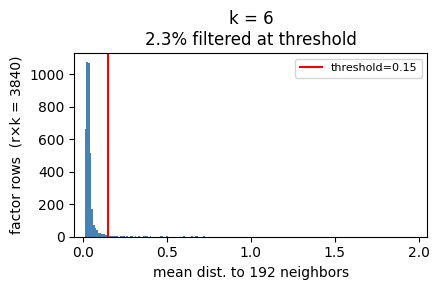

In [10]:
datamodule.setup("predict")

plot_density_histograms(
    model, 
    k_values=[6], 
    density_threshold=0.15, 
    local_neighborhood_size=0.30,
    dataloader=measurement_batches(datamodule, n_batches=20),
    transforms=all_transforms(module),  # empty here; see part 2
    n_replicates=32,
    n_batches=20,
);

In [11]:
datamodule.setup("predict")

start = time.time()
curves = run_measurement_phase(
    model,
    dataloader=measurement_batches(datamodule, n_batches=32),
    transforms=all_transforms(module),  # empty here; see part 2
    n_replicates=32,
    n_batches=32,
    density_threshold=0.5,
    local_neighborhood_size=0.30,
)
print(f"measured {len(K_VALUES)} k values in {time.time() - start:.0f} s")

pd.DataFrame(curves).set_index("k").round(4)

measuring k-selection curves: 100%|██████████| 32/32 [03:05<00:00,  5.79s/it]

measurement phase complete: 32 batches x 11 k values
measured 11 k values in 185 s


,stability,stability_sem,stability_cross,stability_cross_sem,error,error_sem,error_cross,error_cross_sem
k,,,,,,,,
2,0.9943,0.0011,0.9995,0.0001,0.0088,0.0,0.0088,0.0
3,0.9887,0.0014,0.9995,0.0001,0.0045,0.0,0.0045,0.0
4,0.9934,0.0013,0.9999,0.0000,0.0008,0.0,0.0008,0.0
5,0.9820,0.0017,0.9993,0.0001,0.0004,0.0,0.0004,0.0
6,0.9872,0.0019,0.9999,0.0000,0.0001,0.0,0.0001,0.0
7,0.8882,0.0036,0.9997,0.0001,0.0001,0.0,0.0001,0.0
8,0.7830,0.0067,0.8787,0.0169,0.0001,0.0,0.0001,0.0
9,0.6931,0.0100,0.7479,0.0210,0.0001,0.0,0.0001,0.0
10,0.5815,0.0098,0.8370,0.0205,0.0001,0.0,0.0001,0.0


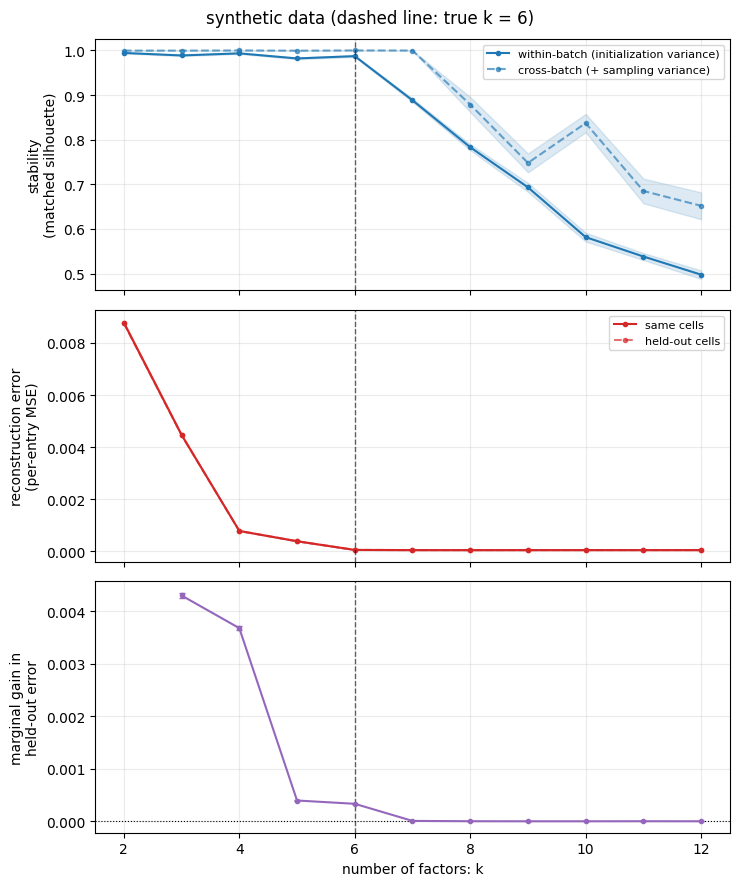

highest cross-batch stability at k = 6
largest k whose marginal gain in held-out error exceeds its own SEM: k = 11


In [12]:
plot_selection(model, k_mark=K_TRUE, title=f"synthetic data (dashed line: true k = {K_TRUE})")
_ = summarize_selection(model)

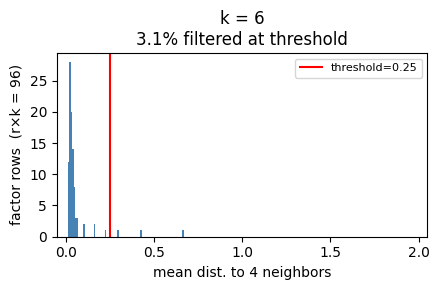

In [13]:
datamodule.setup("predict")

plot_density_histograms(
    model, 
    k_values=[6], 
    density_threshold=0.25, 
    local_neighborhood_size=0.30,
    # dataloader=measurement_batches(datamodule, n_batches=20),
    # transforms=all_transforms(module),  # empty here; see part 2
    # n_replicates=32,
    # n_batches=20,
);

Read the three panels together rather than taking an argmax. Stability stays high while the extra
factors still have reproducible structure to latch onto, and the held-out error stops improving once
there is nothing left to explain — so the marginal-gain panel dropping to zero is the sharpest signal
of where $k$ has run out.

A note on why the held-out error curve is useful at all: cNMF's error is computed on the same cells
the programs were fit from, so it decreases monotonically and cannot be used for selection on its own
— which is exactly why Kotliar needs the stability axis. Scoring the programs on held-out cells makes
the error axis informative too.

## Comparison with ground truth

Infer per-cell loadings at $k = k_{\text{true}}$, then match the recovered programs to the true ones
by Hungarian assignment on cosine similarity (the recovered factors come out in an arbitrary order).

In [14]:
k = K_TRUE

x_transformed, var_names = transformed_matrix(module, adata.X, adata.var_names.to_numpy())

h_inferred = (
    model.infer_loadings(x_transformed, var_names, model.consensus_factors, k=k, normalize=False)
    .detach()
    .cpu()
    .numpy()
)
w_inferred = model.consensus_factors[k]["consensus_D_kg"].detach().cpu().numpy()

order = match_to_reference(w_inferred, W_TRUE)
h_matched = h_inferred[:, order]
w_matched = w_inferred[order]
print("inferred factor matched to each true factor:", order)

inferred factor matched to each true factor: [2 0 4 3 1 5]


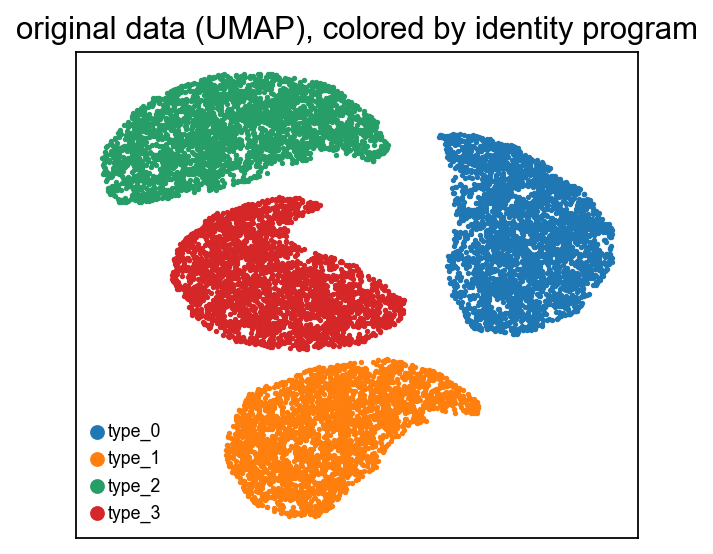

In [15]:
sc.set_figure_params(fontsize=14, vector_friendly=True)

# A couple of minutes on 12k cells.
sc.pp.pca(adata, n_comps=30)
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

umap = adata.obsm["X_umap"]
fig, ax = plt.subplots(figsize=(4.5, 4))
for i, cell_type in enumerate(adata.obs["cell_type"].cat.categories):
    mask = (adata.obs["cell_type"] == cell_type).to_numpy()
    ax.scatter(umap[mask, 0], umap[mask, 1], s=2, label=cell_type, rasterized=True)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("original data (UMAP), colored by identity program")
ax.legend(fontsize=8, markerscale=4, frameon=False)
plt.show()

The four identity programs give discrete clusters; the two activity programs are graded gradients
that cut across all of them. Below, the same UMAP colored by the **true** loadings (top row) and the
**inferred** loadings (bottom row).

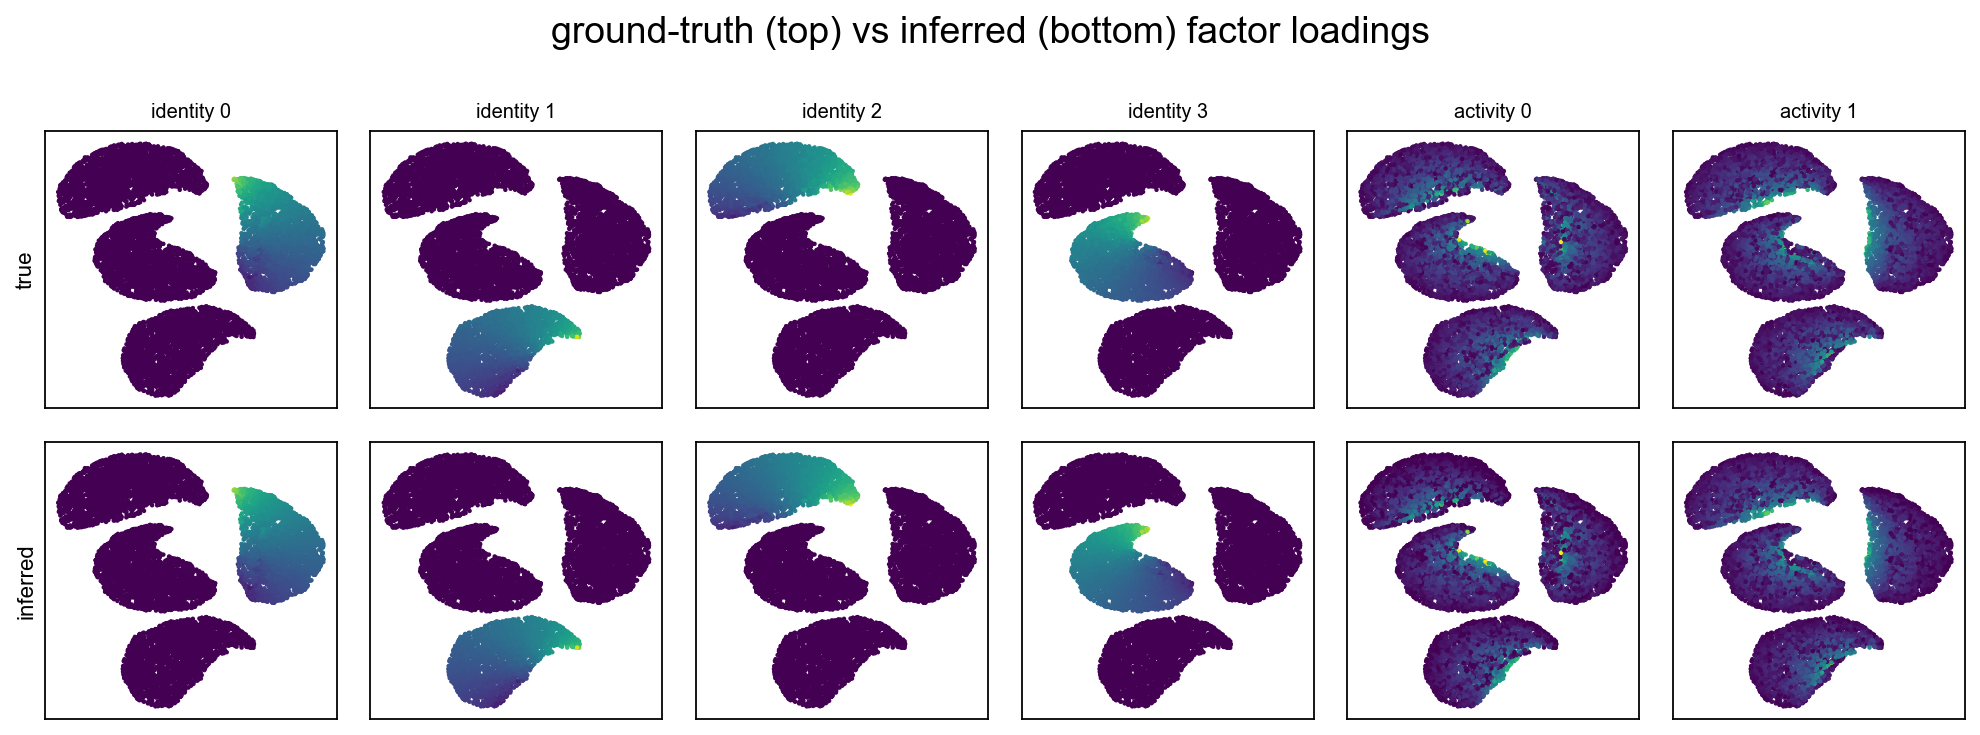

In [16]:
fig, axes = plt.subplots(2, K_TRUE, figsize=(2.1 * K_TRUE, 4.7))
for j in range(K_TRUE):
    for row, (values, tag) in enumerate(((H_TRUE[:, j], "true"), (h_matched[:, j], "inferred"))):
        ax = axes[row, j]
        ax.scatter(umap[:, 0], umap[:, 1], c=values, s=1, cmap="viridis", rasterized=True)
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0:
            ax.set_title(FACTOR_LABELS[j], fontsize=9)
        if j == 0:
            ax.set_ylabel(tag, fontsize=10)
fig.suptitle("ground-truth (top) vs inferred (bottom) factor loadings")
fig.tight_layout()
plt.show()

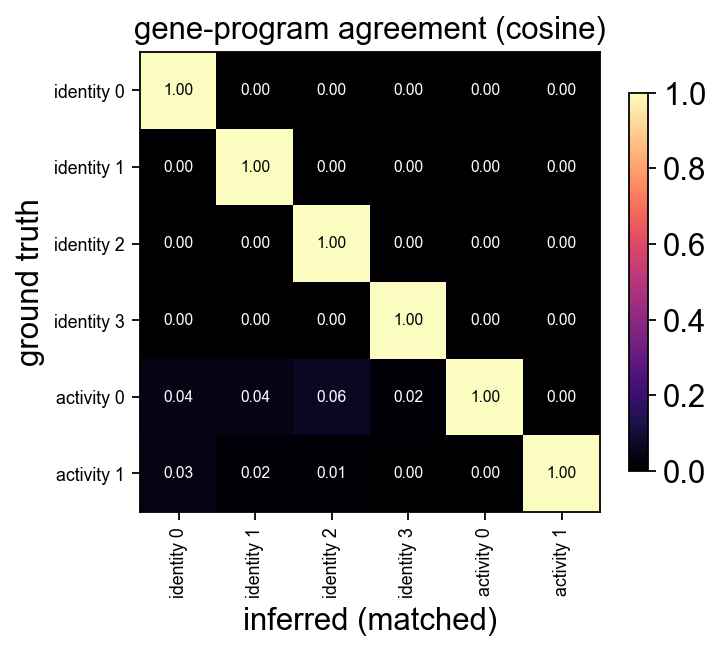

In [17]:
# Factor-level agreement: cosine similarity between every true and every matched inferred program.
def unit_rows(a):
    return a / np.linalg.norm(a, axis=1, keepdims=True).clip(1e-12)


similarity = unit_rows(W_TRUE) @ unit_rows(w_matched).T

fig, ax = plt.subplots(figsize=(4.8, 4.2))
image = ax.imshow(similarity, vmin=0, vmax=1, cmap="magma")
for a in range(K_TRUE):
    for b in range(K_TRUE):
        ax.text(
            b, a, f"{similarity[a, b]:.2f}", ha="center", va="center", fontsize=7,
            color="white" if similarity[a, b] < 0.6 else "black",
        )
ax.set_xticks(range(K_TRUE), FACTOR_LABELS, rotation=90, fontsize=8)
ax.set_yticks(range(K_TRUE), FACTOR_LABELS, fontsize=8)
ax.set_xlabel("inferred (matched)")
ax.set_ylabel("ground truth")
ax.set_title("gene-program agreement (cosine)")
fig.colorbar(image, ax=ax, shrink=0.8)
ax.grid(False)
fig.tight_layout()
plt.show()

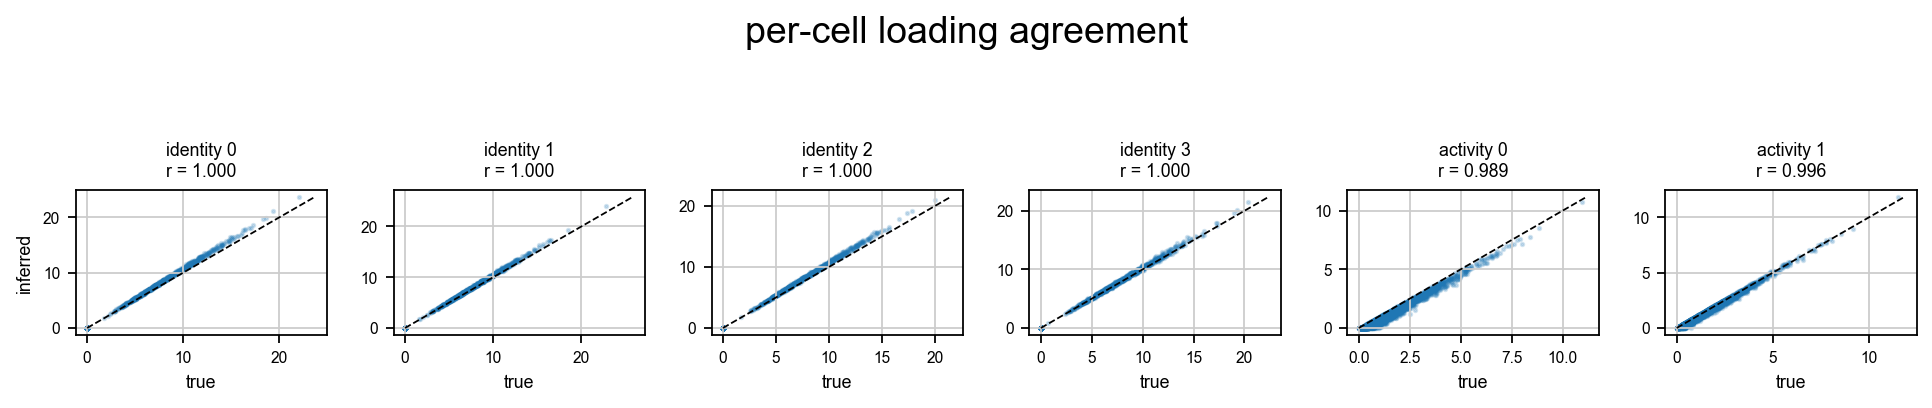

In [18]:
# Cell-level agreement: true vs inferred loading, one panel per program.
rng = np.random.default_rng(0)
subsample = rng.choice(h_matched.shape[0], size=min(3000, h_matched.shape[0]), replace=False)

fig, axes = plt.subplots(1, K_TRUE, figsize=(2.05 * K_TRUE, 2.4))
for j, ax in enumerate(axes):
    true, inferred = H_TRUE[:, j], h_matched[:, j]
    ax.scatter(true[subsample], inferred[subsample], s=2, alpha=0.2, rasterized=True)
    limit = max(true.max(), inferred.max())
    ax.plot([0, limit], [0, limit], "k--", lw=0.8)
    ax.set_title(f"{FACTOR_LABELS[j]}\nr = {np.corrcoef(true, inferred)[0, 1]:.3f}", fontsize=8)
    ax.set_xlabel("true", fontsize=8)
    if j == 0:
        ax.set_ylabel("inferred", fontsize=8)
    ax.tick_params(labelsize=7)
fig.suptitle("per-cell loading agreement", y=1.06)
fig.tight_layout()
plt.show()

Replicate diversity at k=6  (R=64, raw decoder output, no FISTA)
  mean aligned cosine to r=0:  0.862
  min: 0.721   max: 1.000
  (1.0 everywhere = transformer ignoring noise; spread toward 0 = genuine diversity)


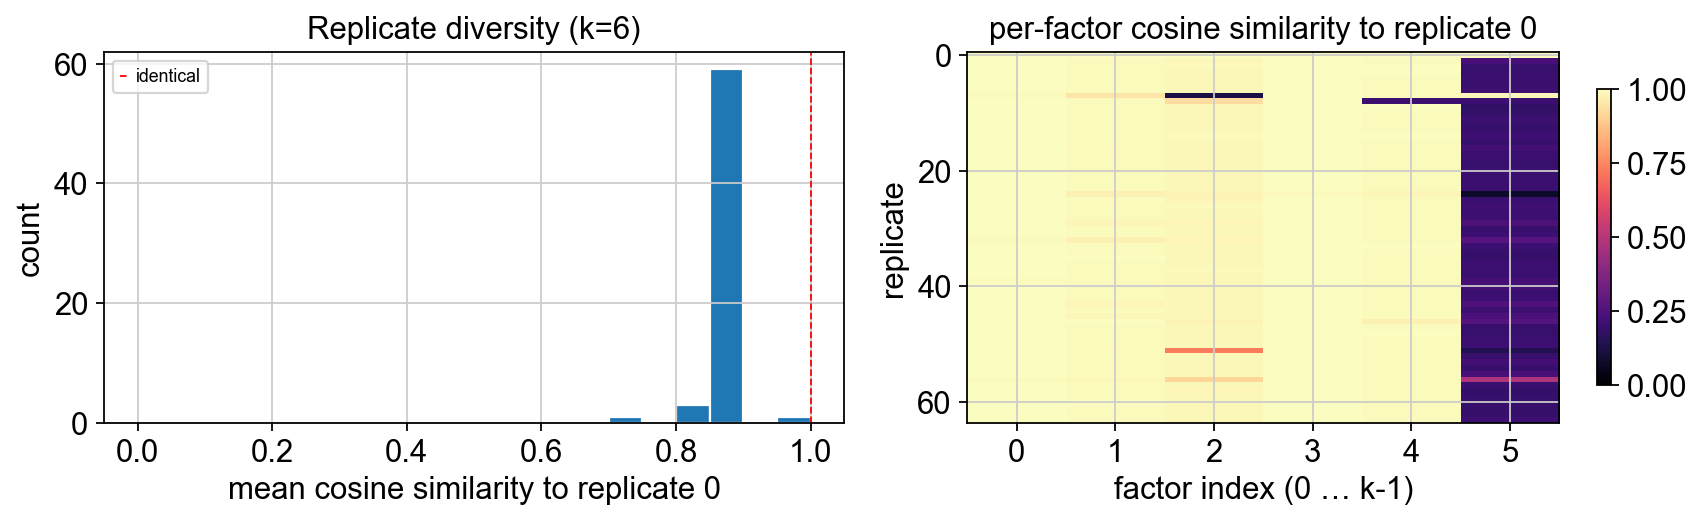

In [19]:
from cellarium.ml.models.cnmf_transformer import align_factors

# One batch, transforms applied
datamodule.setup(stage="predict")
batch = next(iter(datamodule.predict_dataloader()))
x_t, vnames = transformed_matrix(module, batch["x_ng"].float(), batch["var_names_g"])

# Raw decoder W — no FISTA, just the transformer output for R noise seeds
k = K_TRUE
R = model.n_replicates
with torch.no_grad():
    noise = torch.randn(R, k, model.latent_dim)
    w_rkg = model.solve(x_t, k, noise, n_iterations=0, compute_loadings=False)["w_rkg"].cpu()

# Align every replicate to replicate 0 via Sinkhorn, then compute mean cosine sim per replicate
_, cosine_rk, _, _ = align_factors(w_rkg, w_rkg[0])   # cosine_rk: (R, k)
mean_cos_r = cosine_rk.mean(dim=-1)                    # (R,):  1.0 = identical, ~0 = diverse

print(f"Replicate diversity at k={k}  (R={R}, raw decoder output, no FISTA)")
print(f"  mean aligned cosine to r=0:  {mean_cos_r.mean():.3f}")
print(f"  min: {mean_cos_r.min():.3f}   max: {mean_cos_r.max():.3f}")
print(f"  (1.0 everywhere = transformer ignoring noise; spread toward 0 = genuine diversity)")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(mean_cos_r.numpy(), bins=20, range=(0, 1), edgecolor="white")
axes[0].set_xlabel("mean cosine similarity to replicate 0")
axes[0].set_ylabel("count")
axes[0].set_title(f"Replicate diversity (k={k})")
axes[0].axvline(1.0, color="r", lw=0.8, ls="--", label="identical")
axes[0].legend(fontsize=8)

im = axes[1].imshow(cosine_rk.numpy(), aspect="auto", vmin=0, vmax=1, cmap="magma")
axes[1].set_xlabel("factor index (0 … k-1)")
axes[1].set_ylabel("replicate")
axes[1].set_title("per-factor cosine similarity to replicate 0")
fig.colorbar(im, ax=axes[1], shrink=0.8)
fig.tight_layout()
plt.show()


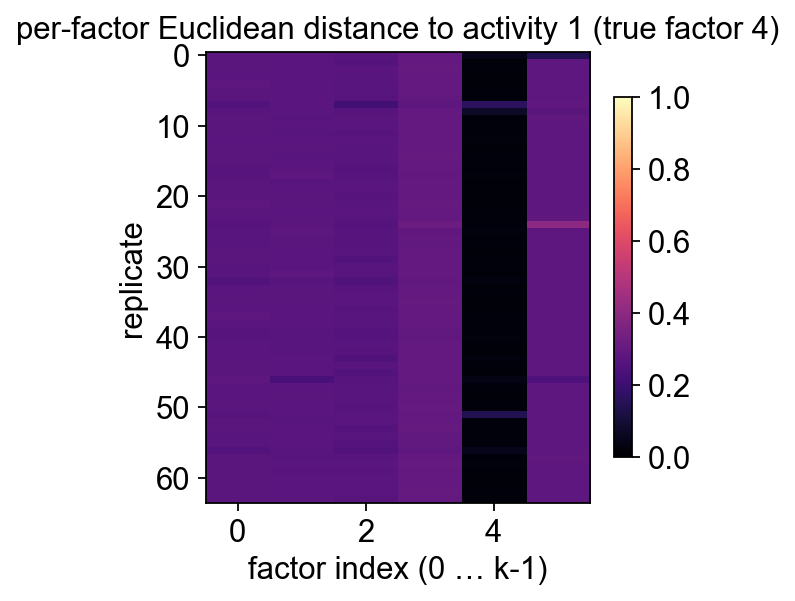

In [20]:
i = 4  # True factor to measure distance to.  Any of the K_TRUE factors

aligned_w_rkg, _, _, _ = align_factors(w_rkg, torch.tensor(W_TRUE))

d_rk = torch.cdist(aligned_w_rkg, torch.tensor(W_TRUE[None, None, i, :]), p=2.0).squeeze()  # (R, k, K_TRUE)  Euclidean distance from each replicate to each true factor

plt.imshow(d_rk.numpy(), aspect="auto", vmin=0, vmax=1, cmap="magma")
plt.xlabel("factor index (0 … k-1)")
plt.ylabel("replicate")
plt.title(f"per-factor Euclidean distance to activity 1 (true factor {i})")
plt.colorbar(shrink=0.8)
plt.grid(False)
plt.tight_layout()
plt.show()

In [21]:
# For each replicate, for each factor: which 33-gene block dominates?
block = x_t.shape[1] // K_TRUE  # genes per block
block_labels = [f"genes {i*block}-{(i+1)*block-1}" for i in range(K_TRUE)]
activity_block_start = N_IDENTITY * block  # first activity gene index

# w_rkg already computed above (R, k, g)
# Sum weight in each gene block per factor
block_weight_rkb = torch.stack(
    [w_rkg[:, :, i*block:(i+1)*block].sum(dim=-1) for i in range(K_TRUE)], dim=-1
)  # (R, k, K_TRUE)

# For each factor slot, what fraction of replicates have their mass in the activity blocks?
activity_fraction_per_slot = (block_weight_rkb[:, :, N_IDENTITY:].sum(dim=-1) > 0.4).float().mean(dim=0)
print("Fraction of replicates with >40% weight in activity gene blocks, per aligned factor slot:")
for slot_i, frac in enumerate(activity_fraction_per_slot):
    print(f"  factor {slot_i}: {frac:.2f}")


Fraction of replicates with >40% weight in activity gene blocks, per aligned factor slot:
  factor 0: 0.27
  factor 1: 0.23
  factor 2: 0.41
  factor 3: 0.45
  factor 4: 0.25
  factor 5: 0.39


### Persisting the result

The measured curves and consensus factors live in **buffers**, so checkpoint *after*
`run_measurement_phase` — otherwise you save an unmeasured model.

In [21]:
# trainer.save_checkpoint("cnmf_transformer_synthetic.ckpt")
# reloaded = CellariumModule.load_from_checkpoint("cnmf_transformer_synthetic.ckpt", map_location="cpu")
# print(
#     "curves survived the round trip:",
#     np.allclose(reloaded.model.selection_curves()["stability"], curves["stability"], equal_nan=True),
# )

---
# 2. PBMC3k

Now a real dataset with cell-type labels, to ask a biological question: do the recovered programs
separate into **cell-type markers** and **pan-cell-type programs**?

`sc.datasets.pbmc3k_processed()` downloads ~24 MB on first use. It carries Louvain cell-type
annotations and a precomputed UMAP, and its `.raw` holds the log-normalized (non-negative) matrix
over all 13,714 genes, which is what NMF needs.

One simplification stated rather than hidden: Kotliar works in linear TPM space, whereas this demo
stays in log space. Everything below is unaffected in kind, but the programs are log-scale programs.

In [41]:
pbmc = sc.datasets.pbmc3k_processed()
pbmc_adata = pbmc.raw.to_adata()

# REVERSE THE LOG1P TO GET RAW COUNTS
dense = pbmc_adata.X.toarray() if scipy.sparse.issparse(pbmc_adata.X) else pbmc_adata.X
raw_counts = np.expm1(dense) # exp(x) - 1

pbmc_adata.X = np.asarray(raw_counts, dtype=np.float32)
pbmc_adata.layers['raw'] = pbmc_adata.X.copy()
pbmc_adata.obs["cell_type"] = pbmc.obs["louvain"].values
pbmc_adata.obsm["X_umap"] = pbmc.obsm["X_umap"]

pbmc_adata = pbmc_adata[:, ~pbmc_adata.var_names.str.startswith("MT-")].copy()
pbmc_adata = pbmc_adata[:, pbmc_adata.var_names != "MALAT1"].copy()

# Kotliar: "We also filtered out genes that were not detected in at least 1 out of 500 cells"
pbmc_adata = pbmc_adata[:, (pbmc_adata.X > 0).sum(axis=0) >= (pbmc_adata.n_obs / 500)].copy()
print(f"Filtered to {pbmc_adata.n_vars} genes expressed in at least 1/500 cells")

sc.pp.normalize_total(pbmc_adata, target_sum=1e6)
hvg_df = kotliar_compute_hvgs(
    mean_g=pbmc_adata.X.mean(axis=0).A1 if scipy.sparse.issparse(pbmc_adata.X) else pbmc_adata.X.mean(axis=0),
    var_g=pbmc_adata.X.var(axis=0).A1 if scipy.sparse.issparse(pbmc_adata.X) else pbmc_adata.X.var(axis=0),
    var_names_g=pbmc_adata.var_names.to_numpy(),
    num_genes=2000,
)
hvg_names = hvg_df.index[hvg_df["highly_variable"]].to_numpy()

# preprocessing without cellarium
def stdscale_quantile_celing(_adata, max_value=None, quantile_thresh=0.9999):
    from scipy.sparse import issparse
    sc.pp.scale(_adata, zero_center=False, max_value=max_value)    
    if quantile_thresh is not None:
        if issparse(_adata.X):
            threshval = np.quantile(np.array(_adata.X.todense()).reshape(-1), quantile_thresh)
        else:
            threshval = np.quantile(_adata.X.reshape(-1), quantile_thresh)
            
        _adata.X[_adata.X > threshval] = threshval  

pbmc_adata.X = pbmc_adata.layers["raw"].copy()
pbmc_adata_hvg = pbmc_adata[:, hvg_names].copy()
sc.pp.normalize_total(pbmc_adata_hvg, target_sum=1e4)
stdscale_quantile_celing(pbmc_adata_hvg, quantile_thresh=0.999)

print(pbmc_adata_hvg.shape, "->", len(hvg_names), "highly variable genes")
print(pbmc_adata.obs["cell_type"].value_counts())

Filtered to 12124 genes expressed in at least 1/500 cells
(2638, 2000) -> 2000 highly variable genes
cell_type
CD4 T cells          1144
CD14+ Monocytes       480
B cells               342
CD8 T cells           316
NK cells              154
FCGR3A+ Monocytes     150
Dendritic cells        37
Megakaryocytes         15
Name: count, dtype: int64


In [42]:
pbmc_adata_hvg.X.min(), pbmc_adata_hvg.X.max(), pbmc_adata_hvg.X.mean(), pbmc_adata_hvg.X.std()

(0.0, 8.107445, 0.20171434, 0.62646836)

In [43]:
hvg_names

array(['ISG15', 'CPSF3L', 'MRPL20', ..., 'SLC19A1', 'S100B', 'PRMT2'],
      dtype=object)

In [48]:
pd.Series(data=pbmc_adata_hvg.X.max(axis=0), index=pbmc_adata_hvg.var_names).sort_values(ascending=False).head(10)

index
ISG15       8.107445
RNASEH2B    8.107445
DHRS4       8.107445
CMTM5       8.107445
METTL3      8.107445
UPF3A       8.107445
CDC16       8.107445
TNFSF13B    8.107445
ARGLU1      8.107445
CLYBL       8.107445
dtype: float32

In [47]:
pd.Series(data=pbmc_adata_hvg.X.mean(axis=0), index=pbmc_adata_hvg.var_names).sort_values(ascending=False).head(10)

index
ACTB      1.594756
HLA-C     1.405252
RPS9      1.395812
RPS3A     1.345948
RPL18     1.313277
RPL10A    1.309983
RPS27A    1.287800
RPSA      1.271797
GNB2L1    1.250641
PFN1      1.242224
dtype: float32

## The real transform stack

Here we use the transforms a production run would use, as `cpu_transforms` on the module so the
dataloader applies them:

- `DivideByScale` by each gene's standard deviation — Kotliar's variance-scaling step;
- `Filter` to the highly variable genes, with `ordering=True` so the output columns follow
  `hvg_names`, which is what the model's `var_names_g` schema is set to.

`dadc` points at the full in-memory `AnnData`; the API is identical to an out-of-core
`DistributedAnnDataCollection`.

In [8]:
K_VALUES_PBMC = list(range(4, 21))

# pbmc_adata.X = pbmc_adata.layers['raw'].copy()

pbmc_datamodule = CellariumAnnDataDataModule(
    dadc=pbmc_adata_hvg,
    batch_size=1024,  # 2 batches/epoch at this dataset size; halves of 512 cells
    shuffle=True,
    drop_incomplete_batch=False,
    batch_keys={
        "x_ng": AnnDataField(attr="X"),
        "var_names_g": AnnDataField(attr="var_names"),
        "obs_names_n": AnnDataField(attr="obs_names"),
    },
)

pbmc_model = CNMFTransformer(
    var_names_g=hvg_names.tolist(),  # post-Filter column order
    k_values=K_VALUES_PBMC,
    latent_dim=128,
    n_iterations=3,
    recurrent=False,
    n_self_attention_heads=8,
    n_replicates=64,
    fista_iterations_train=100,
    curriculum_warmup_steps=500,
    # stability_burn_in_steps=1000,
    drift_settle_steps=1500,
    drift_tol=1e-6,
    outlier_gamma=0.0,
    drift_eval_n_cells=512,
    drift_check_every_n_steps=50,
    measure_at_end=False,
    log_every_n_steps=10,
    use_reservoir=True,
    reservoir_n_bits=8,
    reservoir_max_cells_per_bucket=2,
    reservoir_seed=0,
)

pbmc_module = CellariumModule(
    transforms=[
        # DivideByScale(
        #     scale_g=torch.from_numpy(pbmc_adata.X.std(axis=0)).float(),
        #     var_names_g=pbmc_adata.var_names.to_numpy(),
        #     eps=1e-4,
        # ),
        # Filter(hvg_names.tolist()),
    ],
    model=pbmc_model,
    optim_fn=torch.optim.Adam,
    optim_kwargs={"lr": 1e-4},
)

This is the slow cell — expect **tens of minutes on CPU** for 3000 steps at 1000 genes and $k$ up to
20. Drop `max_steps` for a quick look, or move to a GPU (and drop the `TORCH_COMPILE_DISABLE` line at
the top) for a real run.

In [9]:
pbmc_trainer = pl.Trainer(
    accelerator=ACCELERATOR,
    devices=1,
    max_steps=1000,
    max_epochs=-1,
    logger=False,
    enable_checkpointing=False,
)

start = time.time()
pbmc_trainer.fit(pbmc_module, pbmc_datamodule)
print(f"trained {int(pbmc_model._step)} steps in {(time.time() - start) / 60:.1f} min")

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name     | Type              | Params | Mode 
-------------------------------------------------------
0 | pipeline | CellariumPipeline | 2.0 M  | train
-------------------------------------------------------
2.0 M     Trainable params
129       Non-trainable params
2.0 M     Total params
8.144     Total estimated model params size (MB)
57        Modules in train mode
0         Modules in eval mode


Epoch 333: 100%|██████████| 1/1 [00:00<00:00,  1.12it/s, sc_loss=0.000279, recon_loss=0.207, res_cells=440.0, res_fill=0.859, factor_drift=7.3e-5]  

`Trainer.fit` stopped: `max_steps=1000` reached.


Epoch 333: 100%|██████████| 1/1 [00:00<00:00,  1.12it/s, sc_loss=0.000279, recon_loss=0.207, res_cells=440.0, res_fill=0.859, factor_drift=7.3e-5]
trained 1000 steps in 10.6 min


In [10]:
from cellarium.ml.models.nmf import nmf_compute_factors_fista

@torch.no_grad()
def check_fista_movement(model, x_ng, k=10, r=4):
    device, dtype = x_ng.device, x_ng.dtype
    slot_noise = torch.randn(r, k, model.latent_dim, device=device, dtype=dtype)
    solved = model.solve(x_ng, k, slot_noise, model.fista_iterations_train)
    h, w = solved["h_rnk"], solved["w_rkg"]
    
    # Replicate _compute_w_target logic
    c = h.max().clamp(min=1e-8)
    h_scaled = h / c
    w_scaled = w.detach() * c
    hth = torch.einsum("rnk,rnj->rkj", h_scaled, h_scaled)
    htx = torch.einsum("rnk,ng->rkg", h_scaled, x_ng)
    w_out, history = nmf_compute_factors_fista(w_scaled.contiguous(), hth, htx, max_iter=100)
    
    print(f"FISTA W max-step history: first={history[:5]}, last={history[-5:]}")
    print(f"Total W movement (L∞): {(w_out - w_scaled).abs().max():.6f}")
    # If history is flat near 0, the warm-start was already a fixed point


import torch, torch.nn.functional as F

@torch.no_grad()
def check_factor_collapse(model, x_ng, k=10, r=8):
    import torch.nn.functional as F
    device, dtype = x_ng.device, x_ng.dtype
    slot_noise = torch.randn(r, k, model.latent_dim, device=device, dtype=dtype)
    solved = model.solve(x_ng, k, slot_noise, model.fista_iterations_train)
    w = solved["w_rkg"]       # (r, k, g)

    # Intra-replicate factor similarity (main collapse signal)
    w_norm = F.normalize(w, p=2, dim=-1)
    sim_rkk = torch.einsum("rkg,rjg->rkj", w_norm, w_norm)
    off_diag = sim_rkk[:, ~torch.eye(k, dtype=torch.bool, device=device)]
    print(f"Intra-replicate factor sim: mean={off_diag.mean():.3f}, max={off_diag.max():.3f}")
    # mean > 0.95 → collapse; < 0.5 → genuinely diverse factors

    # Inter-replicate agreement
    cross = torch.einsum("kg,jg->kj", w_norm[0], w_norm[1])
    print(f"Inter-replicate best-match sim: {cross.max(dim=1).values.mean():.3f}")
    # High + low intra-sim → good; low + low → incoherent; high + high → collapse



In [11]:
from cellarium.ml.utilities.core import call_func_with_batch


# Get a batch from the dataloader
pbmc_datamodule.setup(stage="predict")
dl = pbmc_datamodule.predict_dataloader()
batch = next(iter(dl))

# Apply your transforms (same as you do in run_measurement_phase)
for transform in all_transforms(pbmc_module):
    batch |= call_func_with_batch(transform.forward, batch)

x_ng = batch["x_ng"].to(pbmc_model.device)

# Then call whichever diagnostic you want
check_factor_collapse(pbmc_model, x_ng, k=10, r=8)
check_fista_movement(pbmc_model, x_ng, k=10, r=4)


Intra-replicate factor sim: mean=0.779, max=0.998
Inter-replicate best-match sim: 0.980
FISTA W max-step history: first=tensor([1.5562, 0.4609, 0.2904, 0.2623, 0.2847]), last=tensor([0.0240, 0.0241, 0.0240, 0.0237, 0.0231])
Total W movement (L∞): 8.971608


In [12]:
# Are cells being distributed across slots in the hot-start, or does one slot win?
with torch.no_grad():
    x_emb = pbmc_model.encoder(torch.log1p(x_ng))
    cond = pbmc_model._k_cond(10, x_ng.device, x_ng.dtype)
    noise = torch.randn(4, 10, pbmc_model.latent_dim, device=x_ng.device, dtype=x_ng.dtype)
    slots = pbmc_model._initial_slots(10, noise, cond, x_emb)
    # run through blocks
    kn = pbmc_model.to_key(x_emb)
    vn = pbmc_model.to_value(x_emb)
    for i in range(pbmc_model.n_iterations):
        idx = 0 if pbmc_model.recurrent else i
        slots = pbmc_model.blocks[idx](slots, kn, vn, cond)
    logits = torch.einsum("rke,ne->rkn", pbmc_model.norm_hot_start(slots), x_emb)
    assignments = logits.argmax(dim=-2)  # (r, n) — which slot each cell goes to
    for r in range(4):
        counts = assignments[r].bincount(minlength=10)
        print(f"Replicate {r} slot assignments: {counts.tolist()}")


Replicate 0 slot assignments: [107, 245, 29, 5, 2, 1, 167, 12, 0, 456]
Replicate 1 slot assignments: [15, 88, 195, 239, 1, 3, 430, 50, 2, 1]
Replicate 2 slot assignments: [58, 356, 91, 41, 21, 56, 63, 251, 14, 73]
Replicate 3 slot assignments: [241, 2, 208, 106, 249, 20, 102, 30, 22, 44]


In [13]:
@torch.no_grad()
def autopsy_forward_pass(model, x_ng, k=10):
    print("--- 1. DATA HEALTH ---")
    print(f"x_ng: min={x_ng.min():.3f}, max={x_ng.max():.3f}, mean={x_ng.mean():.3f}")
    print(f"Total counts per cell: mean={x_ng.sum(-1).mean():.3f}, std={x_ng.sum(-1).std():.3f}")

    print("\n--- 2. ENCODER HEALTH (Is the student blind?) ---")
    x_emb_ne = model.encoder(torch.log1p(x_ng))
    sim_nn = torch.einsum("ne,me->nm", F.normalize(x_emb_ne, dim=-1), F.normalize(x_emb_ne, dim=-1))
    off_diag_sim = sim_nn[~torch.eye(x_ng.shape[0], dtype=torch.bool)].mean()
    print(f"Average pairwise cell similarity: {off_diag_sim:.4f}")
    if off_diag_sim > 0.95:
        print(">>> DANGER: All cells look identical to the encoder. The manifold has collapsed!")

    print("\n--- 3. INITIALIZATION HEALTH (Are seeds diverse?) ---")
    slot_noise = torch.randn(1, k, model.latent_dim, device=x_ng.device, dtype=x_ng.dtype)
    cond_e = model._k_cond(k, x_ng.device, x_ng.dtype)
    slots_initial = model._initial_slots(k, slot_noise, cond_e, x_emb_ne)
    sim_kk = torch.einsum("ke,je->kj", F.normalize(slots_initial[0], dim=-1), F.normalize(slots_initial[0], dim=-1))
    off_diag_slots = sim_kk[~torch.eye(k, dtype=torch.bool)].mean()
    print(f"Average pairwise slot seed similarity: {off_diag_slots:.4f}")

    print("\n--- 4. TEACHER HEALTH (Is FISTA moving?) ---")
    solved = model.solve(x_ng, k, slot_noise, model.fista_iterations_train)
    w_student = solved["w_rkg"]
    w_target = model._compute_w_target(x_ng, solved["h_rnk"], w_student)
    
    diff = (w_target - w_student).abs().mean()
    print(f"Mean absolute update from Teacher to Student: {diff:.6e}")
    if diff < 1e-6:
        print(">>> DANGER: The teacher is taking zero-sized steps. FISTA is paralyzed!")
    else:
        print("SUCCESS: FISTA is actively correcting the student.")

In [14]:
autopsy_forward_pass(pbmc_model, x_ng, k=10)

--- 1. DATA HEALTH ---
x_ng: min=0.000, max=2.780, mean=0.190
Total counts per cell: mean=379.411, std=39.809

--- 2. ENCODER HEALTH (Is the student blind?) ---
Average pairwise cell similarity: 0.5132

--- 3. INITIALIZATION HEALTH (Are seeds diverse?) ---
Average pairwise slot seed similarity: 0.6896

--- 4. TEACHER HEALTH (Is FISTA moving?) ---
Mean absolute update from Teacher to Student: 2.411163e-04
SUCCESS: FISTA is actively correcting the student.


measuring k-selection curves: 100%|██████████| 8/8 [06:31<00:00, 48.91s/it]


measurement phase complete: 8 batches x 17 k values
measured 17 k values in 6.5 min


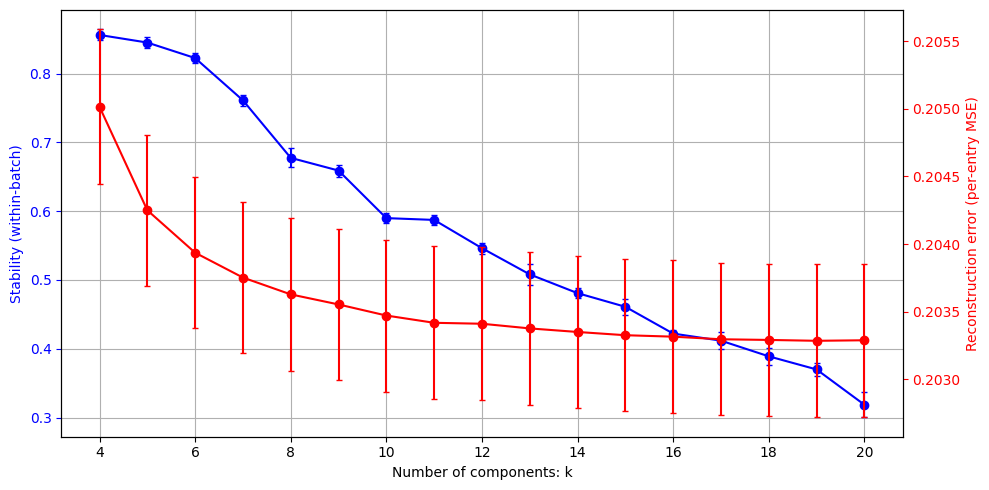

In [15]:
pbmc_datamodule.setup(stage="predict")

start = time.time()
pbmc_curves = run_measurement_phase(
    pbmc_model,
    dataloader=measurement_batches(pbmc_datamodule, n_batches=8),
    transforms=all_transforms(pbmc_module),  # cpu_transforms are back in the module after fit
    n_replicates=64,
    density_threshold=0.5, 
    local_neighborhood_size=0.30,
    n_batches=8,
)
print(f"measured {len(K_VALUES_PBMC)} k values in {(time.time() - start) / 60:.1f} min")

plot_k_selection(pbmc_model)  # the built-in one-liner

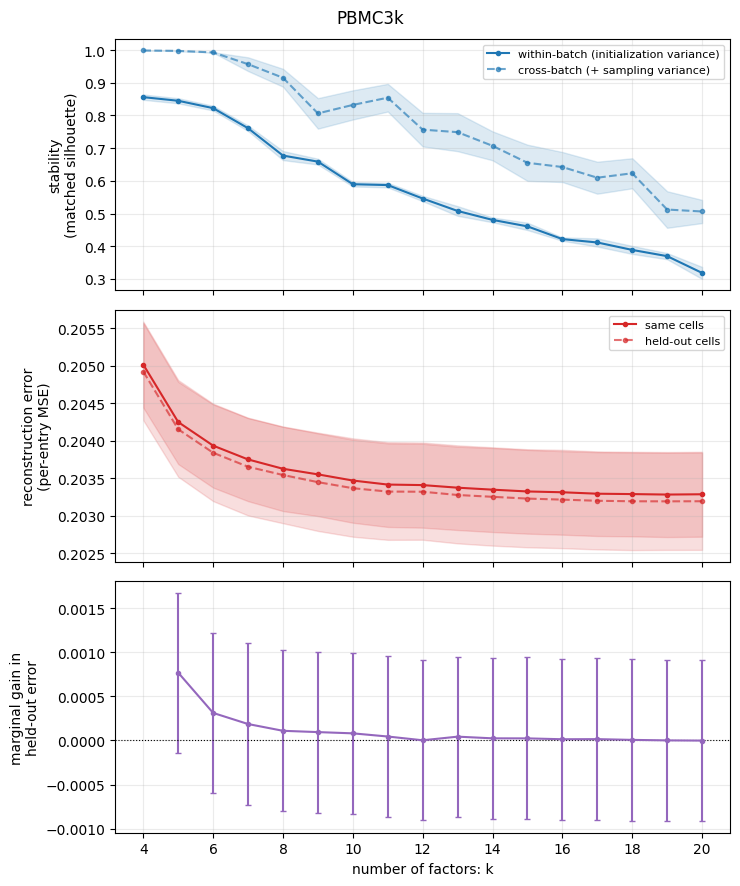

highest cross-batch stability at k = 4
largest k whose marginal gain in held-out error exceeds its own SEM: k = 4


In [16]:
plot_selection(pbmc_model, title="PBMC3k")
_, K_SUGGESTED = summarize_selection(pbmc_model)

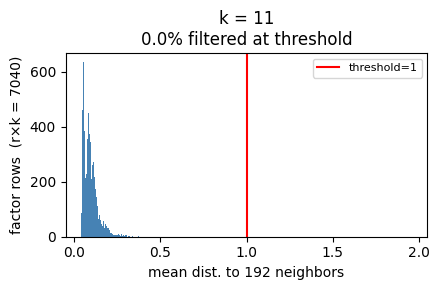

In [17]:
pbmc_datamodule.setup("predict")

plot_density_histograms(
    pbmc_model, 
    k_values=[11], 
    density_threshold=1, 
    local_neighborhood_size=0.3,
    dataloader=measurement_batches(pbmc_datamodule, n_batches=20),
    transforms=all_transforms(pbmc_module),  # empty here; see part 2
    n_replicates=32,
    n_batches=20,
);

## Programs versus cell-type labels

Pick a $k$ from the curves above and infer loadings for every cell, normalized so each cell's
loadings sum to 1 — i.e. the fraction of that cell's expression each program accounts for.

Then average per cell type and sort the programs by a **specificity** score,
$1 - H(\text{profile}) / \log(\text{n cell types})$: near 1 means the program loads on a single cell
type, near 0 means it loads evenly on all of them. Sorting by it is what makes the split visible
rather than leaving the reader to hunt for it.

In [19]:
# Override this by hand after reading the curves above.  The default -- the largest k whose marginal
# gain in held-out error was still resolvable above its own standard error -- is a defensible
# automatic choice, but the whole point of the figure is that this is a judgement call.
# K_PBMC = K_SUGGESTED
K_PBMC = 11
print("using k =", K_PBMC)

x_pbmc, pbmc_var_names = transformed_matrix(pbmc_module, pbmc_adata_hvg.X, pbmc_adata_hvg.var_names.to_numpy())
h_pbmc = (
    pbmc_model.infer_loadings(x_pbmc, pbmc_var_names, pbmc_model.consensus_factors, k=K_PBMC, normalize=True)
    .detach()
    .cpu()
    .numpy()
)

loadings = pd.DataFrame(h_pbmc, columns=[f"f{j}" for j in range(K_PBMC)])
loadings["cell_type"] = pbmc_adata_hvg.obs["cell_type"].to_numpy()
mean_by_type = loadings.groupby("cell_type", observed=True).mean().T  # factors x cell types

profile = mean_by_type.div(mean_by_type.sum(axis=1), axis=0)
p = profile.to_numpy().clip(1e-12)
specificity = 1.0 + (p * np.log(p)).sum(axis=1) / np.log(profile.shape[1])
order = np.argsort(-specificity)

profile = profile.iloc[order]
specificity = specificity[order]
profile.round(3)

using k = 11


cell_type,B cells,CD14+ Monocytes,CD4 T cells,CD8 T cells,Dendritic cells,FCGR3A+ Monocytes,Megakaryocytes,NK cells
f6,0.970,0.000,0.008,0.007,0.000,0.012,0.000,0.003
f10,0.924,0.008,0.037,0.022,0.000,0.000,0.000,0.009
f4,0.929,0.005,0.011,0.019,0.027,0.003,0.000,0.008
f0,0.022,0.024,0.003,0.003,0.914,0.022,0.012,0.000
f7,0.002,0.000,0.016,0.488,0.000,0.002,0.447,0.044
f5,0.051,0.012,0.704,0.178,0.015,0.006,0.000,0.033
f3,0.004,0.002,0.008,0.109,0.017,0.049,0.086,0.724
f9,0.032,0.008,0.637,0.262,0.001,0.002,0.005,0.052
f1,0.011,0.004,0.114,0.700,0.000,0.013,0.126,0.031
f2,0.003,0.357,0.007,0.003,0.134,0.339,0.152,0.004


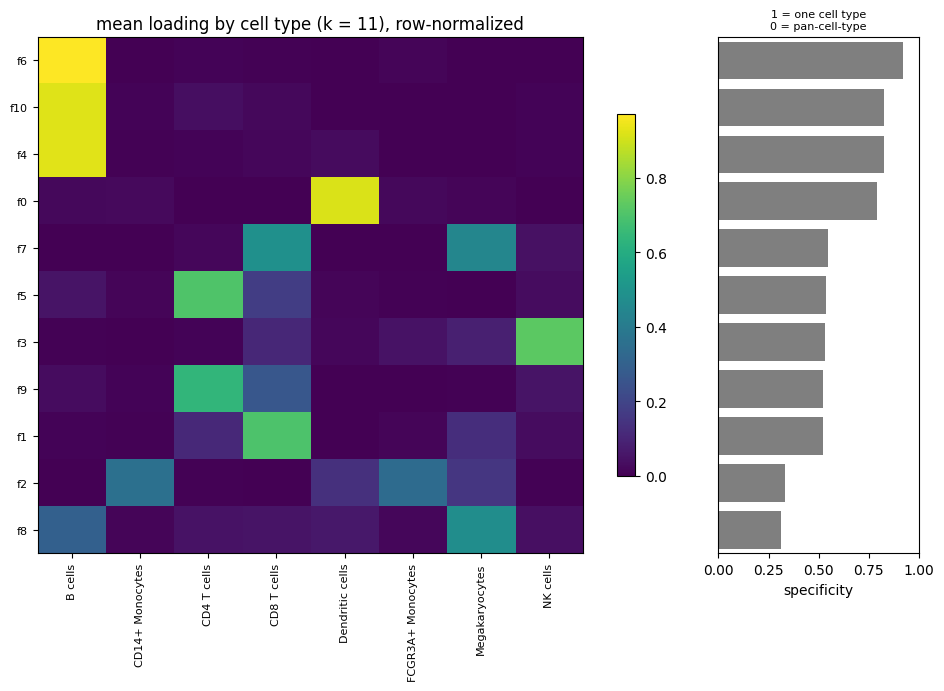

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 0.42 * K_PBMC + 2.4), gridspec_kw={"width_ratios": [3.4, 1]})

image = axes[0].imshow(profile.to_numpy(), aspect="auto", cmap="viridis")
axes[0].set_xticks(range(profile.shape[1]), profile.columns, rotation=90, fontsize=8)
axes[0].set_yticks(range(profile.shape[0]), profile.index, fontsize=8)
axes[0].set_title(f"mean loading by cell type (k = {K_PBMC}), row-normalized")
axes[0].grid(False)
fig.colorbar(image, ax=axes[0], shrink=0.7)

axes[1].barh(range(profile.shape[0]), specificity, color="tab:grey")
axes[1].set_ylim(profile.shape[0] - 0.5, -0.5)  # match imshow's inverted y axis
axes[1].set_yticks([])
axes[1].set_xlim(0, 1)
axes[1].set_xlabel("specificity")
axes[1].set_title("1 = one cell type\n0 = pan-cell-type", fontsize=8)
axes[1].grid(False)

fig.tight_layout()
plt.show()

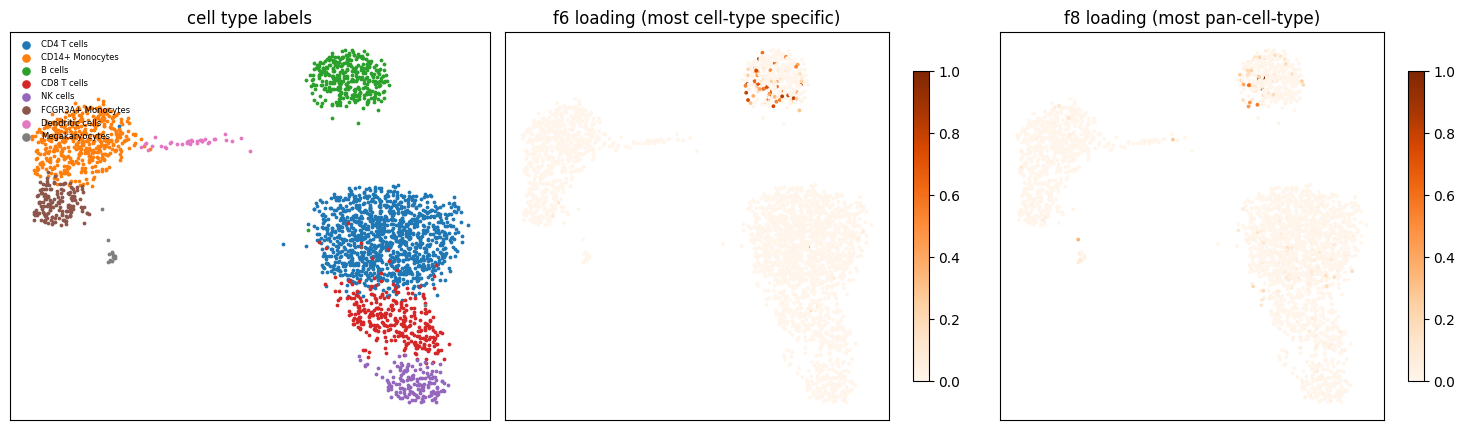

In [21]:
# The most specific and the most pan-cell-type program, on the precomputed UMAP.
specific_factor = int(profile.index[0][1:])
pan_factor = int(profile.index[-1][1:])
pbmc_umap = pbmc_adata.obsm["X_umap"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for i, cell_type in enumerate(pbmc_adata.obs["cell_type"].cat.categories):
    mask = (pbmc_adata.obs["cell_type"] == cell_type).to_numpy()
    axes[0].scatter(pbmc_umap[mask, 0], pbmc_umap[mask, 1], s=3, label=cell_type, rasterized=True)
axes[0].legend(fontsize=6, markerscale=3, frameon=False, loc="upper left")
axes[0].set_title("cell type labels")

for ax, factor, tag in (
    (axes[1], specific_factor, "most cell-type specific"),
    (axes[2], pan_factor, "most pan-cell-type"),
):
    points = ax.scatter(pbmc_umap[:, 0], pbmc_umap[:, 1], c=h_pbmc[:, factor], s=3, cmap="Oranges", vmax=1, rasterized=True)
    ax.set_title(f"f{factor} loading ({tag})")
    fig.colorbar(points, ax=ax, shrink=0.8)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()
plt.show()

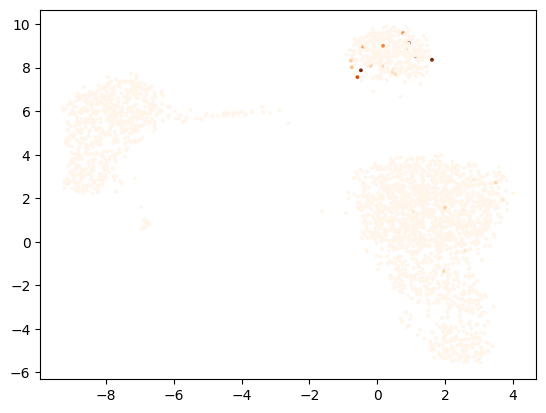

In [35]:
plt.scatter(pbmc_umap[:, 0], pbmc_umap[:, 1], c=h_pbmc[:, 10], s=3, cmap="Oranges", vmax=0.5, rasterized=True)

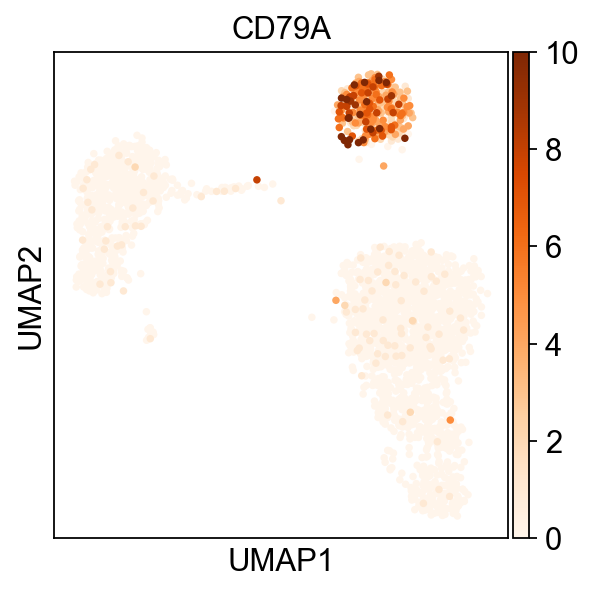

In [94]:
sc.pl.embedding(pbmc_adata, basis='umap', color='CD79A', color_map='Oranges', vmax=10)

In [92]:
np.where(hvg_names == 'CD79A')

(array([1876]),)

In [95]:
w_pbmc[:, np.where(hvg_names == 'CD79A')[0]]

array([[2.4226776e-05],
       [1.4819670e-09],
       [1.0187204e-03],
       [4.5192297e-04],
       [4.4708631e-05],
       [1.4186674e-04],
       [1.2013226e-05],
       [3.5944227e-05],
       [5.3004333e-05],
       [7.2190619e-06],
       [1.7669502e-06],
       [9.9343748e-04]], dtype=float32)

In [38]:
hvg_names[np.argsort(-w_pbmc[10])[:11]]

array(['CD74', 'HLA-DRA', 'HLA-DPB1', 'HLA-DRB1', 'HLA-DPA1', 'HLA-C',
       'CD37', 'HLA-DRB5', 'GNB2L1', 'MALAT1', 'MS4A1'], dtype=object)

An independent sanity check: the top-weighted genes of those two programs. A cell-type-specific
program should read as a recognizable marker set.

In [37]:
w_pbmc = pbmc_model.consensus_factors[K_PBMC]["consensus_D_kg"].detach().cpu().numpy()
pd.DataFrame(
    {
        f"f{specific_factor} (specific)": hvg_names[np.argsort(-w_pbmc[specific_factor])[:10]],
        f"f{pan_factor} (pan-cell-type)": hvg_names[np.argsort(-w_pbmc[pan_factor])[:10]],
    }
)

,f6 (specific),f8 (pan-cell-type)
0,CD74,CD74
1,HLA-DRA,HLA-DRA
2,HLA-DPB1,HLA-DPB1
3,HLA-DRB1,HLA-DRB1
4,HLA-DPA1,HLA-DPA1
5,CD37,HLA-C
6,HLA-DRB5,HLA-DQA2
7,CD79B,HLA-DRB5
8,MALAT1,CD37
9,MS4A1,MS4A1


---
# Where to go from here

Once you have picked a $k$, there are two distinct things you might want, and they call for
different moves.

**Polish the programs at your chosen $k$.** `export_hot_start` hands the measured consensus factors
to `AmortizedOnlineNonNegativeMatrixFactorization`, which shares the same L1-normalized-row
convention and can run the full solver online over an entire out-of-core dataset.

**Reproduce a Kotliar-comparable stability number.** Run that model **cold**, with independent random
initializations. Hot starting a consensus run partly defeats the consensus: Kotliar's $r$ replicates
are meant to explore different basins, and that independence is what makes the downstream silhouette
meaningful. Seeding them all from one consensus makes them converge together and inflates stability
regardless of whether the programs are real.

In [ ]:
hot_start = export_hot_start(pbmc_model, k_values=[K_PBMC], r=1)
print({k: tuple(v.shape) for k, v in hot_start.items()})